In [1]:
# define custom dataset
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torchvision.io import decode_image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import matplotlib.pyplot as plt

In [2]:
os.listdir('/kaggle/input/seefoodfhj-2024')

['sample_submission.csv',
 'labelnames.csv',
 'train.csv',
 'test.csv',
 'test',
 'train']

In [3]:
class CustomImageDataset(Dataset):
    def __init__(self, anotation_file, image_folder, transform=None, target_transform=None):
        self.img_labes = pd.read_csv(anotation_file)
        self.img_dir = image_folder
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labes)

    def __getitem__(self, idx):
        image_path = os.path.join(self.img_dir, f'{self.img_labes.iloc[idx, 0]}.jpg')
        image = Image.open(image_path)
        label = self.img_labes.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label


In [4]:
dir_name = '/kaggle/input/seefoodfhj-2024'

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # force all images to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform = transforms.Compose([
    transforms.Resize(512),
    transforms.CenterCrop(512),
    transforms.ToTensor()
])

train_dataset = CustomImageDataset(f'{dir_name}/train.csv', f'{dir_name}/train', transform)
# test_dataset = CustomImageDataset(f'{dir_name}/test.csv', f'{dir_name}/test', ToTensor)

shape of x [N, C, H, W]: torch.Size([128, 3, 512, 512])
Feature batch shape: torch.Size([128, 3, 512, 512])
Labels batch shape: torch.Size([128])


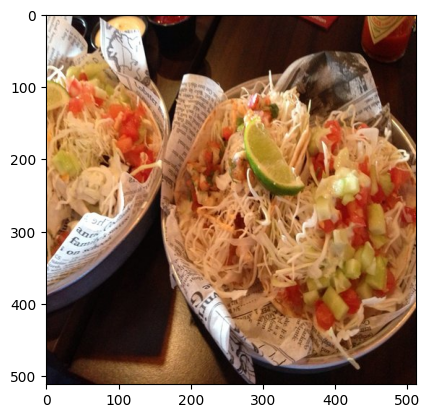

Label: 96


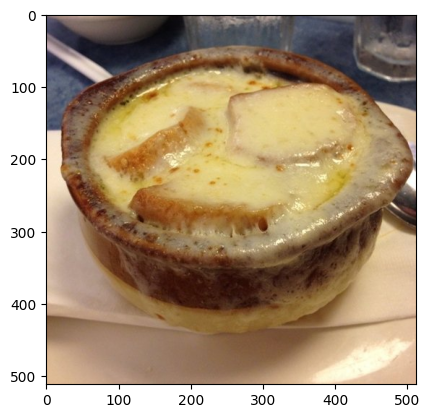

Label: 41


In [5]:
batch_size = 128

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# # test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
# for x in train_dataloader:
#   print(f'shape of x [N, C, H, W]: {x.shape}')
#   # print(f'shape of y: {y.shape} {y.dtype}')
#   break

for train_features, train_labels in train_dataloader:
    print(f'shape of x [N, C, H, W]: {train_features.shape}')
    print(f"Feature batch shape: {train_features.size()}")
    print(f"Labels batch shape: {train_labels.size()}")
    for i in range(2):
        label = train_labels[i]
        img = train_features[i]        # shape [3, 224, 224]
        img = img.permute(1, 2, 0)     # now [224, 224, 3]
        plt.imshow(img)
        plt.show()
        print(f"Label: {label}")
    break

In [6]:
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else 'cpu'
print(f'device = {device}')

device = cuda


In [1]:
from torch.nn import Function as fn
class ImageCNN(nn.Module):
    def __init__(self, no_channel, no_class):
        super().__init__()
        self.conv1 = fn.

SyntaxError: incomplete input (3168624208.py, line 3)